# Histology tile generation
Short walkthrough of unconditional and conditional histology tile synthesis.

In [1]:
import lazyslide as zs

wsi = zs.datasets.sample()

/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)


/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/wsidata/io/_wsi.py:136: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = read_zarr(store)


## Unconditional generation
Generate tiles without providing any input context.

In [2]:
images = zs.tl.image_generation()

/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


model_index.json:   0%|          | 0.00/254 [00:00<?, ?B/s]

pipeline.py:   0%|          | 0.00/9.80k [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

...

scheduling_euler_maruyama.py:   0%|          | 0.00/8.36k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

sit.py:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

Keyword arguments {'trust_remote_code': True} are not expected by CytoSynPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

This returns a list of PIL images; inspect the first sample.

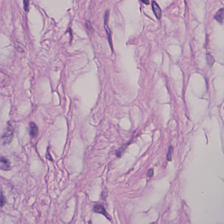

In [3]:
images[0]

## Conditional generation
Control synthesis using prior information such as tile features.

In [4]:
zs.tl.feature_extraction(wsi, "h0-mini")

config.json:   0%|          | 0.00/832 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Output()

Condition on the first tile feature vector.

In [5]:
images = zs.tl.image_generation(wsi, model="cytosyn", prompt_tiles=0)

Keyword arguments {'trust_remote_code': True} are not expected by CytoSynPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

Compare the conditioning tile with generated samples.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

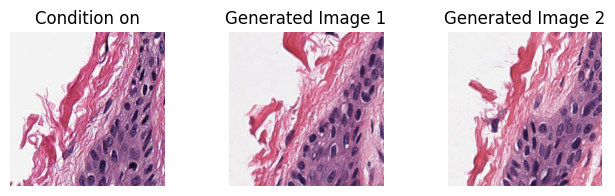

In [6]:
import matplotlib.pyplot as plt

for tile in wsi.iter.tile_images("tiles"):
    break

_, axes = plt.subplots(1, 3, figsize=(8, 2))
axes[0].imshow(tile.image)
axes[0].set_title("Condition on")
axes[0].axis("off")

axes[1].imshow(images[0])
axes[1].set_title("Generated Image 1")
axes[1].axis("off")

axes[2].imshow(images[1])
axes[2].set_title("Generated Image 2")
axes[2].axis("off")